In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Local Jupyter: keep the CSV in the same folder as this notebook.
# Google Colab: upload the CSV to the Colab session first, then run this cell.
csv_file = "Day13_Restaurant_Branch_Performance_Dataset.csv"

df = pd.read_csv(csv_file)
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (350, 22)


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,"4,977.25",172,135,375.75,"66,766.77","27,954.29","46,554.90","20,211.87",29.00,4.44,20.80,70.30,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,"8,998.30",285,263,530.64,"157,230.89","63,816.59","96,813.95","60,416.94",27.90,4.56,31.30,70.70,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,"10,034.97",306,264,534.97,"155,811.96","54,874.10","89,888.91","65,923.05",30.20,4.36,21.40,61.50,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,"5,095.84",198,167,370.05,"80,574.05","31,429.44","53,531.82","27,042.23",21.70,4.65,22.90,40.40,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,"6,681.82",148,116,364.62,"56,579.89","21,759.51","44,376.25","12,203.64",26.10,4.50,29.00,44.30,Clear,Combo Deal


In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df.info()

Rows: 350
Columns: 22

Column names:
['Record_ID', 'Date', 'Day', 'Month', 'Branch', 'Region', 'Store_Type', 'Staff_Count', 'Marketing_Spend', 'Customers', 'Orders', 'Average_Bill', 'Revenue', 'Food_Cost', 'Operating_Cost', 'Profit', 'Avg_Delivery_Min', 'Customer_Rating', 'Temperature_C', 'Humidity_Percent', 'Weather', 'Promotion']

Data types:


,Data Type
Record_ID,str
Date,datetime64[us]
Day,str
Month,str
Branch,str
Region,str
Store_Type,str
Staff_Count,int64
Marketing_Spend,float64
Customers,int64



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Record_ID         350 non-null    str           
 1   Date              350 non-null    datetime64[us]
 2   Day               350 non-null    str           
 3   Month             350 non-null    str           
 4   Branch            350 non-null    str           
 5   Region            350 non-null    str           
 6   Store_Type        350 non-null    str           
 7   Staff_Count       350 non-null    int64         
 8   Marketing_Spend   350 non-null    float64       
 9   Customers         350 non-null    int64         
 10  Orders            350 non-null    int64         
 11  Average_Bill      350 non-null    float64       
 12  Revenue           350 non-null    float64       
 13  Food_Cost         350 non-null    float64       
 14  Operating_Cost 

In [3]:
print("Missing values by column:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing.to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values for selected categorical columns:")
for col in ["Branch", "Region", "Store_Type", "Weather", "Promotion"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

Missing values by column:


,Missing Values
Promotion,184
Record_ID,0
Day,0
Month,0
Branch,0
Date,0
Region,0
Store_Type,0
Marketing_Spend,0
Staff_Count,0



Duplicate rows: 0

Unique values for selected categorical columns:

Branch:
Branch
Srinagar     52
Jaipur       48
Kochi        48
Bengaluru    46
Mumbai       44
Hyderabad    43
Pune         37
Delhi        32
Name: count, dtype: int64

Region:
Region
South    137
North    132
West      81
Name: count, dtype: int64

Store_Type:
Store_Type
Standard    196
Express     102
Premium      52
Name: count, dtype: int64

Weather:
Weather
Clear     189
Cloudy     82
Rain       48
Hot        31
Name: count, dtype: int64

Promotion:
Promotion
NaN              184
Weekend Offer     74
Combo Deal        59
Loyalty Offer     33
Name: count, dtype: int64


In [4]:
numeric_cols = df.select_dtypes(include="number").columns

summary = df[numeric_cols].describe().T
summary["IQR"] = summary["75%"] - summary["25%"]
summary["CV_%"] = (summary["std"] / summary["mean"]) * 100

display(summary.round(2))

,count,mean,std,min,25%,50%,75%,max,IQR,CV_%
Staff_Count,350.00,11.96,4.34,5.00,9.00,11.00,15.00,24.00,6.00,36.28
Marketing_Spend,350.00,"5,516.35","2,050.91",725.35,"4,339.73","5,393.37","6,748.50","11,784.96","2,408.77",37.18
Customers,350.00,217.38,56.72,77.00,180.25,213.00,255.75,360.00,75.50,26.09
Orders,350.00,187.05,50.56,71.00,155.00,182.50,218.75,334.00,63.75,27.03
Average_Bill,350.00,388.91,82.49,180.00,337.32,383.48,441.76,623.28,104.45,21.21
Revenue,350.00,"86,831.80","36,644.45","20,540.76","61,261.72","79,766.88","102,976.18","194,018.92","41,714.47",42.20
Food_Cost,350.00,"31,807.55","13,896.89","7,262.01","22,326.66","28,861.32","38,370.37","75,946.59","16,043.71",43.69
Operating_Cost,350.00,"56,621.44","18,467.84","20,782.38","43,797.67","53,723.02","63,961.23","111,489.14","20,163.56",32.62
Profit,350.00,"30,210.36","19,508.59","-6,924.68","16,915.49","26,873.87","39,823.74","89,096.19","22,908.25",64.58
Avg_Delivery_Min,350.00,26.10,4.39,13.90,22.80,26.10,29.08,38.30,6.28,16.81


In [5]:
categorical_cols = ["Day", "Month", "Branch", "Region", "Store_Type", "Weather", "Promotion"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).to_frame("Count"))

print("\nAverage business performance:")
display(df[["Customers", "Orders", "Revenue", "Profit", "Marketing_Spend",
            "Staff_Count", "Avg_Delivery_Min", "Customer_Rating"]].mean().to_frame("Mean").round(2))


--- Day ---


,Count
Day,
Tuesday,56
Saturday,55
Monday,54
Wednesday,50
Friday,47
Sunday,47
Thursday,41



--- Month ---


,Count
Month,
February,65
January,62
June,61
March,58
April,56
May,48



--- Branch ---


...

,Count
Weather,
Clear,189
Cloudy,82
Rain,48
Hot,31



--- Promotion ---


,Count
Promotion,
NaN,184
Weekend Offer,74
Combo Deal,59
Loyalty Offer,33



Average business performance:


,Mean
Customers,217.38
Orders,187.05
Revenue,"86,831.80"
Profit,"30,210.36"
Marketing_Spend,"5,516.35"
Staff_Count,11.96
Avg_Delivery_Min,26.10
Customer_Rating,4.47


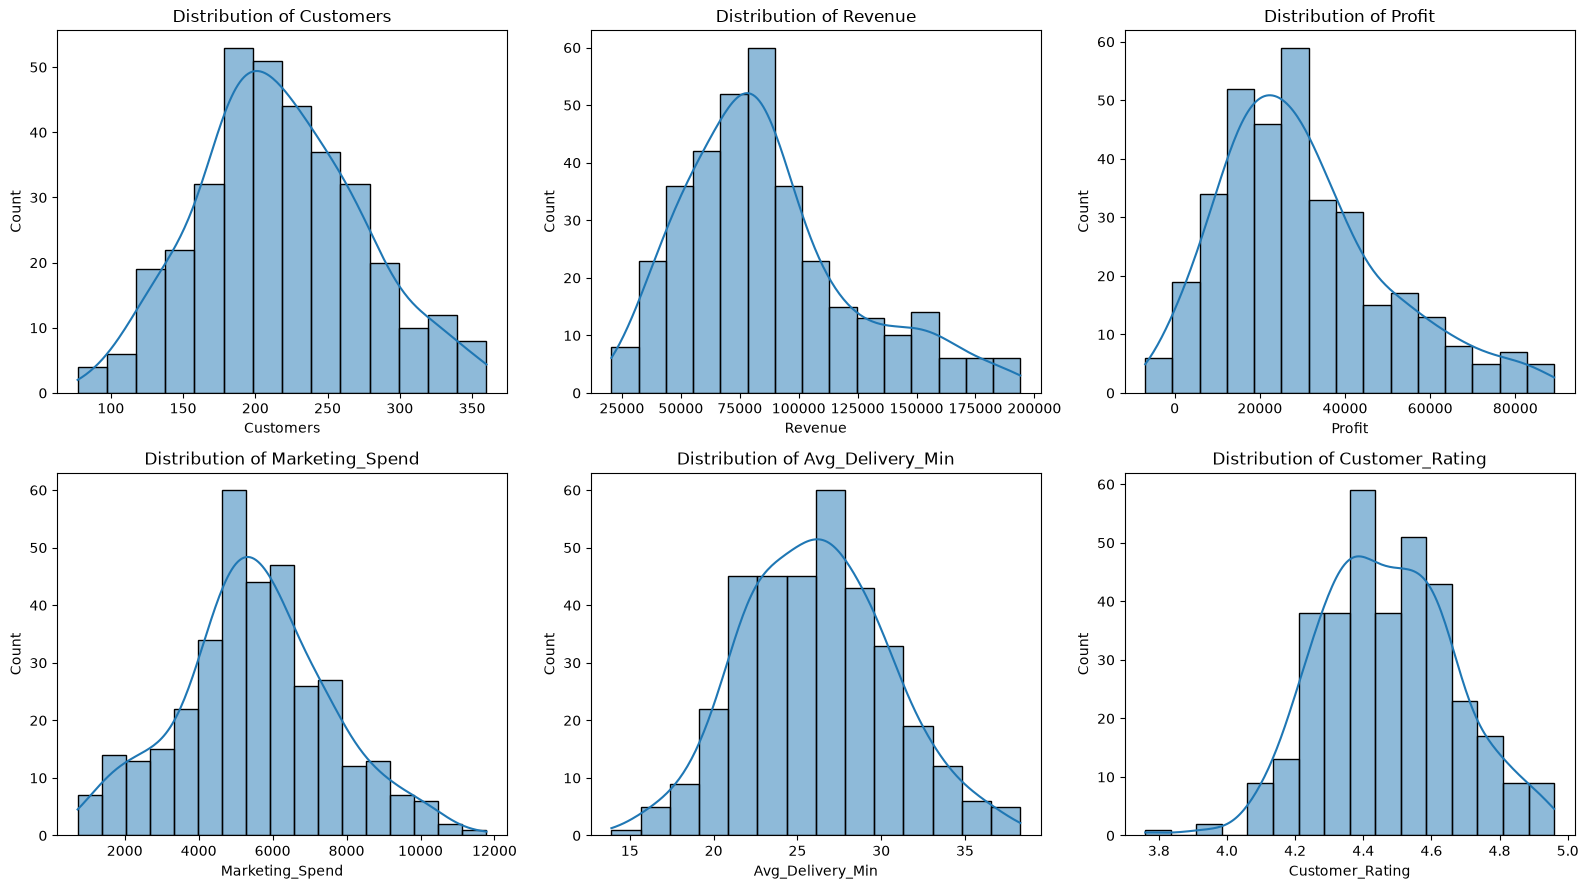

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_cols = ["Customers", "Revenue", "Profit", "Marketing_Spend", "Avg_Delivery_Min", "Customer_Rating"]

for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

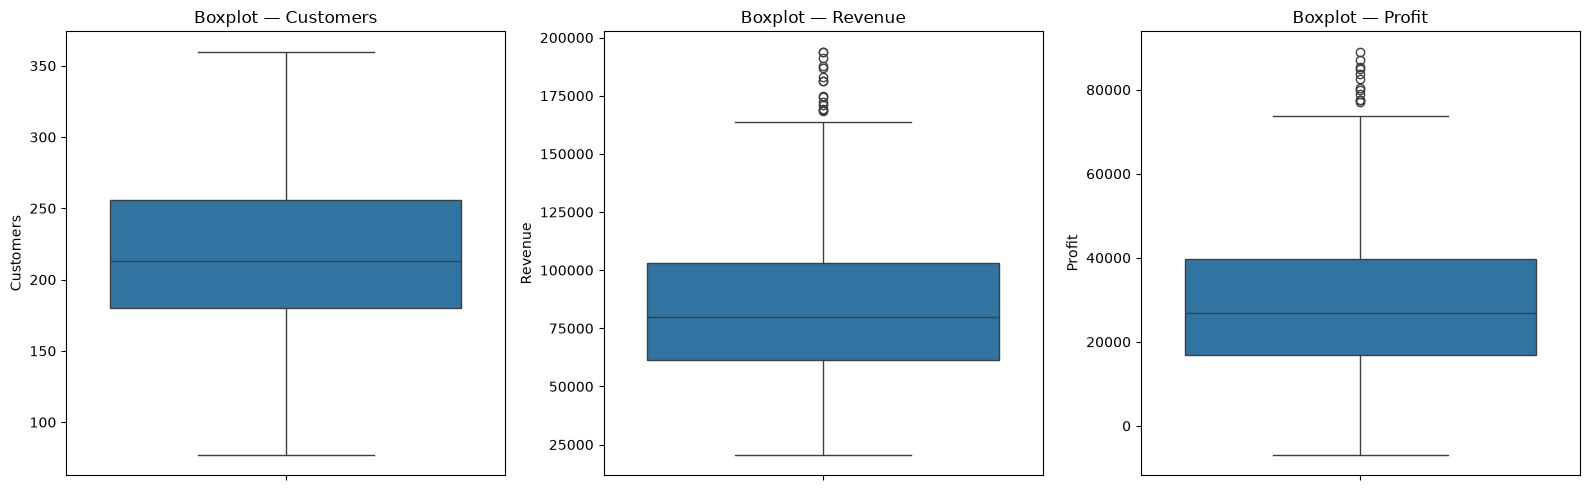

,Variable,Lower Bound,Upper Bound,IQR Outlier Count
7,Operating_Cost,"13,552.33","94,206.56",18
5,Revenue,"-1,309.98","165,547.89",15
6,Food_Cost,"-1,738.90","62,435.93",13
8,Profit,"-17,446.88","74,186.12",12
1,Marketing_Spend,726.57,"10,361.66",5
4,Average_Bill,180.64,598.44,4
3,Orders,59.38,314.38,3
11,Temperature_C,14.50,40.90,2
10,Customer_Rating,3.90,5.02,1
2,Customers,67.00,369.00,0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["Customers", "Revenue", "Profit"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot — {col}")
plt.tight_layout()
plt.show()

# IQR-based outlier counts for descriptive purposes only
outlier_rows = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append([col, lower, upper, count])

outlier_summary = pd.DataFrame(outlier_rows, columns=["Variable", "Lower Bound", "Upper Bound", "IQR Outlier Count"])
display(outlier_summary.sort_values("IQR Outlier Count", ascending=False).round(2))

In [8]:
branch_perf = df.groupby("Branch").agg(
    Records=("Record_ID", "count"),
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Rating=("Customer_Rating", "mean"),
    Avg_Delivery=("Avg_Delivery_Min", "mean")
).sort_values("Avg_Profit", ascending=False)

display(branch_perf.round(2))

,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Rating,Avg_Delivery
Branch,,,,,,
Bengaluru,46,227.50,"90,732.12","31,890.91",4.47,26.56
Hyderabad,43,220.79,"88,804.90","31,402.98",4.47,25.52
Delhi,32,213.97,"87,573.87","31,385.30",4.49,25.69
Pune,37,214.92,"88,107.49","31,265.57",4.54,25.53
Jaipur,48,223.27,"86,746.16","30,469.70",4.47,26.58
Srinagar,52,214.73,"86,746.47","30,302.92",4.48,25.97
Kochi,48,209.06,"85,574.62","28,902.04",4.42,25.84
Mumbai,44,213.77,"80,779.25","26,580.99",4.44,26.86


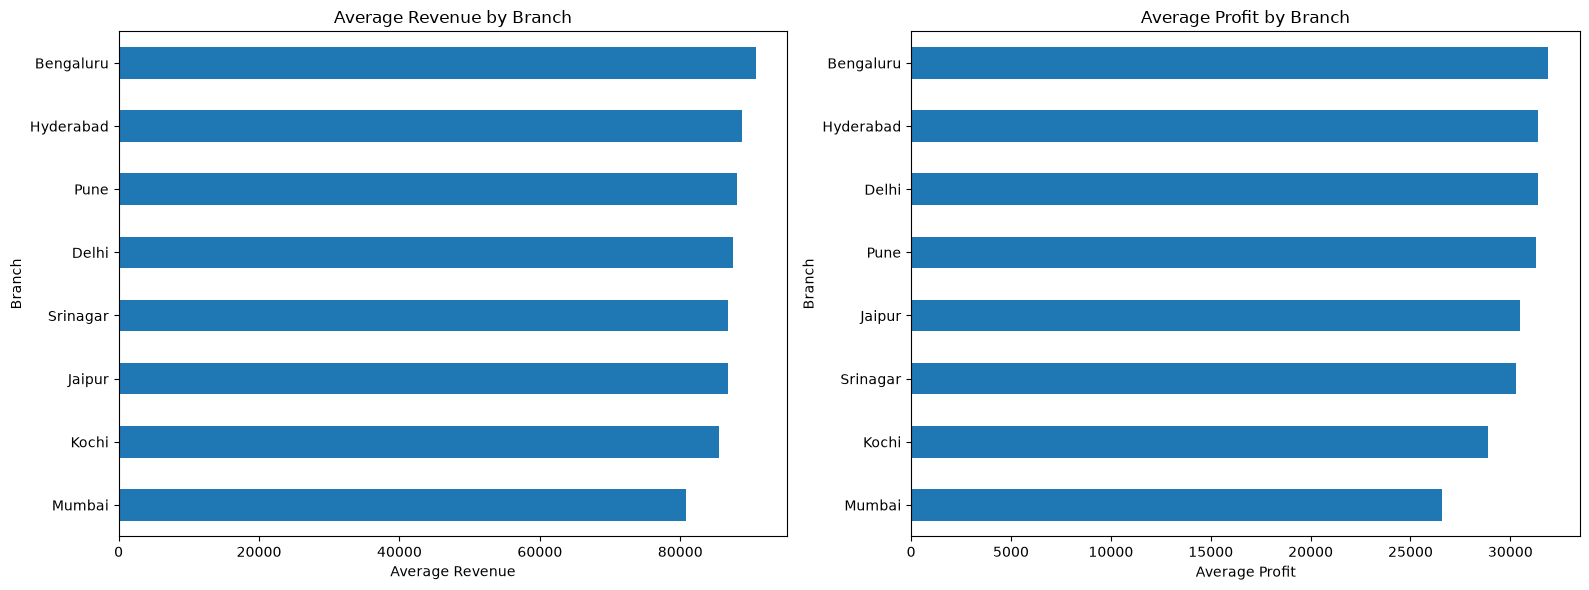

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

branch_perf["Avg_Revenue"].sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Average Revenue by Branch")
axes[0].set_xlabel("Average Revenue")

branch_perf["Avg_Profit"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Average Profit by Branch")
axes[1].set_xlabel("Average Profit")

plt.tight_layout()
plt.show()

,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Rating,Avg_Delivery
Region,,,,,,
South,137,218.93,"88,320.22","30,690.57",4.45,25.98
North,132,217.65,"86,946.94","30,625.96",4.48,26.13
West,81,214.30,"84,126.72","28,720.86",4.49,26.25


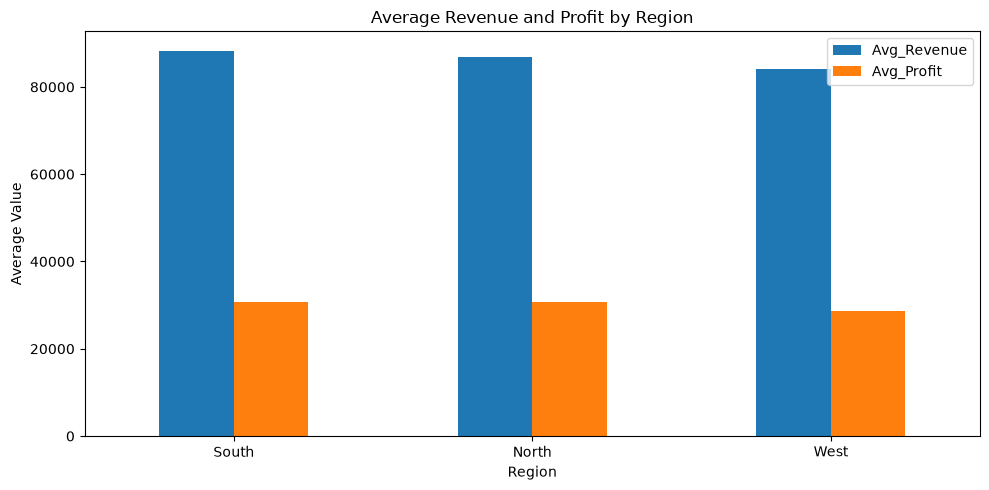

In [10]:
region_perf = df.groupby("Region").agg(
    Records=("Record_ID", "count"),
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Rating=("Customer_Rating", "mean"),
    Avg_Delivery=("Avg_Delivery_Min", "mean")
).sort_values("Avg_Profit", ascending=False)

display(region_perf.round(2))

region_perf[["Avg_Revenue", "Avg_Profit"]].plot(kind="bar", figsize=(10, 5))
plt.title("Average Revenue and Profit by Region")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Rating,Avg_Delivery
Store_Type,,,,,,
Premium,52,298.73,"152,867.31","62,890.24",4.46,26.40
Standard,196,224.98,"87,268.67","30,630.79",4.47,25.98
Express,102,161.29,"52,327.16","12,742.14",4.46,26.17


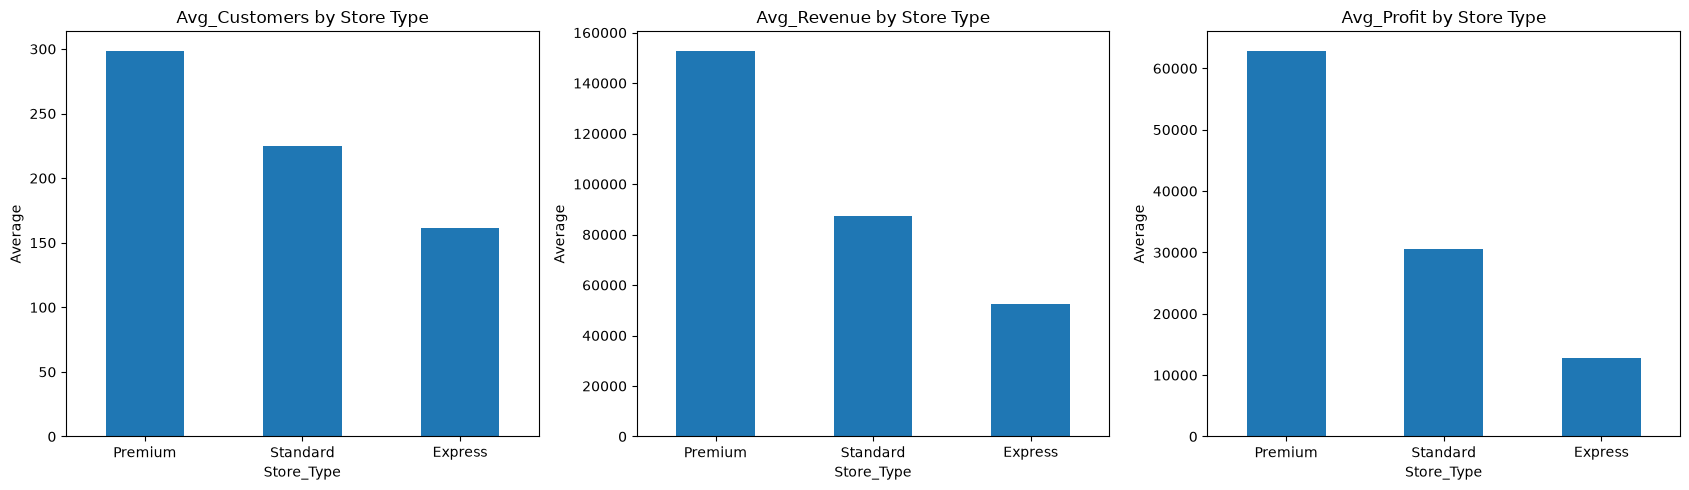

In [11]:
store_perf = df.groupby("Store_Type").agg(
    Records=("Record_ID", "count"),
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Rating=("Customer_Rating", "mean"),
    Avg_Delivery=("Avg_Delivery_Min", "mean")
).sort_values("Avg_Profit", ascending=False)

display(store_perf.round(2))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, ["Avg_Customers", "Avg_Revenue", "Avg_Profit"]):
    store_perf[col].plot(kind="bar", ax=ax)
    ax.set_title(f"{col} by Store Type")
    ax.set_ylabel("Average")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

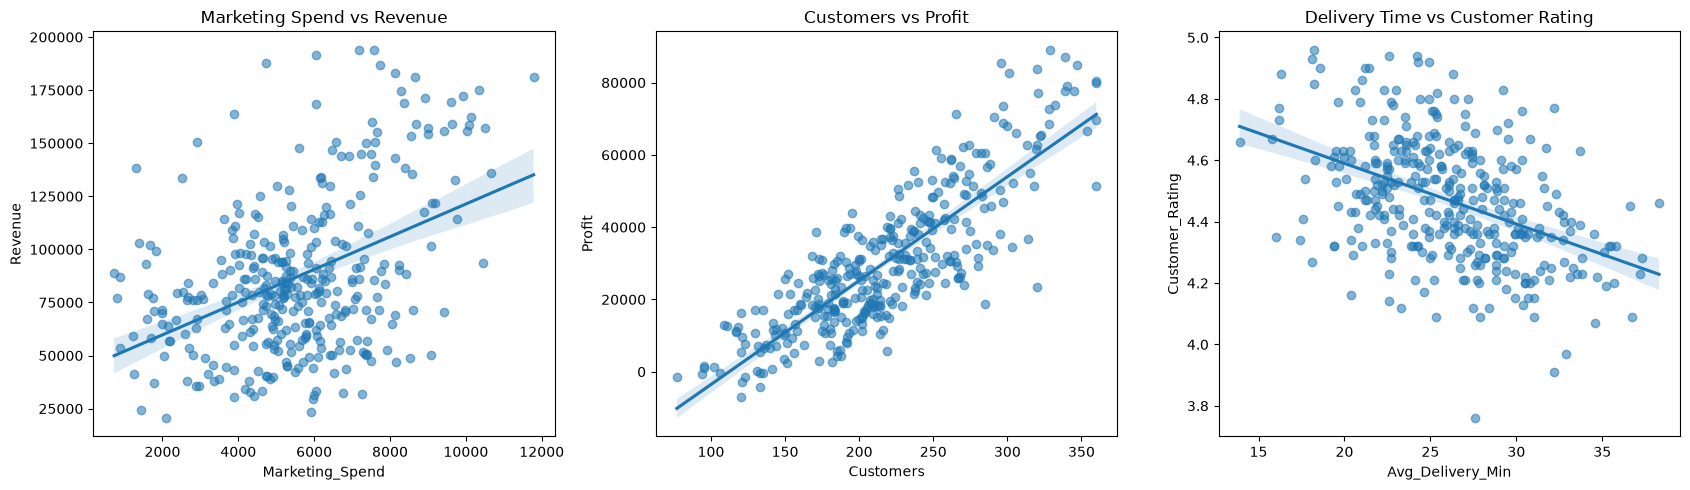

Average performance by promotion status:


,Records,Avg_Customers,Avg_Revenue,Avg_Profit
Promotion,,,,
Loyalty Offer,33,226.97,"91,937.89","32,346.09"
Weekend Offer,74,224.54,"88,808.72","31,730.63"
Combo Deal,59,218.64,"86,269.73","29,779.94"
No Promotion,184,212.37,"85,301.20","29,353.92"


In [12]:
# Relationship-focused scatter plots
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.regplot(data=df, x="Marketing_Spend", y="Revenue", scatter_kws={"alpha": 0.55}, ax=axes[0])
axes[0].set_title("Marketing Spend vs Revenue")

sns.regplot(data=df, x="Customers", y="Profit", scatter_kws={"alpha": 0.55}, ax=axes[1])
axes[1].set_title("Customers vs Profit")

sns.regplot(data=df, x="Avg_Delivery_Min", y="Customer_Rating", scatter_kws={"alpha": 0.55}, ax=axes[2])
axes[2].set_title("Delivery Time vs Customer Rating")

plt.tight_layout()
plt.show()

print("Average performance by promotion status:")
promo_df = df.copy()
promo_df["Promotion"] = promo_df["Promotion"].fillna("No Promotion")
promo_perf = promo_df.groupby("Promotion").agg(
    Records=("Record_ID", "count"),
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean")
).sort_values("Avg_Profit", ascending=False)

display(promo_perf.round(2))

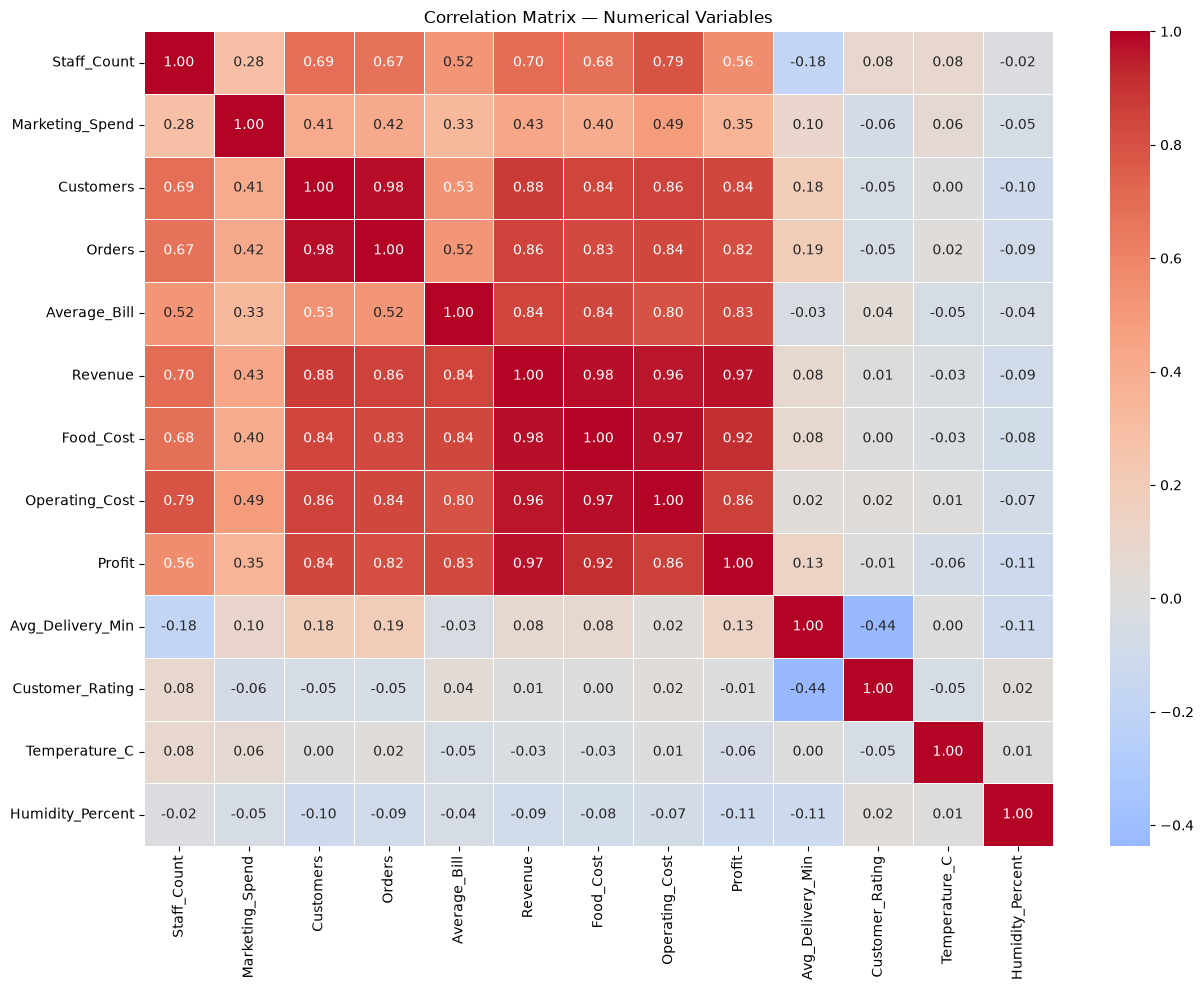

Variables most positively/negatively correlated with Profit:


,Correlation with Profit
Revenue,0.97
Food_Cost,0.92
Operating_Cost,0.86
Customers,0.84
Average_Bill,0.83
Orders,0.81
Staff_Count,0.56
Marketing_Spend,0.35
Avg_Delivery_Min,0.13
Customer_Rating,-0.01


In [13]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation Matrix — Numerical Variables")
plt.tight_layout()
plt.show()

print("Variables most positively/negatively correlated with Profit:")
profit_corr = corr["Profit"].drop("Profit").sort_values(ascending=False)
display(profit_corr.to_frame("Correlation with Profit").round(3))

In [14]:
# Automatically display the key figures used in the conclusions
best_branch = branch_perf.index[0]
worst_branch = branch_perf.index[-1]
best_store = store_perf.index[0]
best_region = region_perf.index[0]

print(f"1. Dataset size: {len(df)} records across {df['Branch'].nunique()} branches, "
      f"{df['Region'].nunique()} regions, and {df['Store_Type'].nunique()} store types.")
print(f"2. Average customers = {df['Customers'].mean():.2f}; average revenue = {df['Revenue'].mean():.2f}; "
      f"average profit = {df['Profit'].mean():.2f}.")
print(f"3. {best_branch} has the highest average branch profit ({branch_perf.loc[best_branch, 'Avg_Profit']:.2f}), "
      f"while {worst_branch} has the lowest ({branch_perf.loc[worst_branch, 'Avg_Profit']:.2f}).")
print(f"4. {best_store} stores lead on average revenue ({store_perf.loc[best_store, 'Avg_Revenue']:.2f}) "
      f"and profit ({store_perf.loc[best_store, 'Avg_Profit']:.2f}), with average customers of "
      f"{store_perf.loc[best_store, 'Avg_Customers']:.2f}.")
print(f"5. {best_region} has the highest average regional profit ({region_perf.loc[best_region, 'Avg_Profit']:.2f}) "
      f"among the three regions.")
print(f"6. Profit has correlation {corr.loc['Profit','Revenue']:.3f} with revenue and "
      f"{corr.loc['Profit','Customers']:.3f} with customers, showing strong positive linear associations.")
print(f"7. Profit has correlation {corr.loc['Profit','Marketing_Spend']:.3f} with marketing spend, "
      f"which is positive but substantially weaker than the revenue/profit relationship.")
print(f"8. Profit has correlation {corr.loc['Profit','Customer_Rating']:.3f} with customer rating, "
      f"indicating almost no linear association in this dataset.")

1. Dataset size: 350 records across 8 branches, 3 regions, and 3 store types.
2. Average customers = 217.38; average revenue = 86831.80; average profit = 30210.36.
3. Bengaluru has the highest average branch profit (31890.91), while Mumbai has the lowest (26580.99).
4. Premium stores lead on average revenue (152867.31) and profit (62890.24), with average customers of 298.73.
5. South has the highest average regional profit (30690.57) among the three regions.
6. Profit has correlation 0.967 with revenue and 0.836 with customers, showing strong positive linear associations.
7. Profit has correlation 0.350 with marketing spend, which is positive but substantially weaker than the revenue/profit relationship.
8. Profit has correlation -0.005 with customer rating, indicating almost no linear association in this dataset.
